# Evaluating the CNN-BiLSTM with Attention Model
In this notebook, we load the trained `CNNBiLSTMAttention` model checkpoint and evaluate its performance on the test dataset.

In [1]:
import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
PROC_DIR = "."
test_df = pd.read_csv("../Datasets/test_interpolated.csv")

# Ensure test_df label strings are mapped to integers using the classes mapped in labels.json
import json
from sklearn.preprocessing import LabelEncoder
with open("../api/labels.json", "r", encoding="utf-8") as f:
    labels_dict = json.load(f)
classes = [labels_dict[str(i)]["id"] for i in range(len(labels_dict))]
le = LabelEncoder()
le.fit(classes)
test_df['label'] = le.transform(test_df['label'])

In [3]:
class SignDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = np.load(f"{PROC_DIR}/{row.file}").astype(np.float32)
        y = int(row.label)
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.df)

test_loader = DataLoader(SignDataset(test_df), batch_size=32)

In [4]:
import torch.nn as nn

class CNNBiLSTMAttention(nn.Module):
    def __init__(self, input_dim=387, num_classes=401, conv_filters=128, lstm_hidden=128, num_layers=2, dropout=0.3):
        super().__init__()
        # Input shape: (B, T, F)
        # conv1 expects channels first, so we will transpose the input to (B, F, T)
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels=input_dim, out_channels=conv_filters, kernel_size=3, padding=1),
            nn.BatchNorm1d(conv_filters),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv1d(in_channels=conv_filters, out_channels=conv_filters, kernel_size=3, padding=1),
            nn.BatchNorm1d(conv_filters),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        # BiLSTM layer
        self.lstm = nn.LSTM(
            input_size=conv_filters,
            hidden_size=lstm_hidden,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        
        # Self-attention mechanism over the LSTM outputs (lstm_hidden * 2 due to bidirectionality)
        self.attention = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        
        self.fc = nn.Linear(lstm_hidden * 2, num_classes)
        
    def forward(self, x):
        # x shape: (B, T, F)
        # Transpose for Conv1d: (B, F, T)
        x = x.transpose(1, 2)
        x = self.conv1(x) # (B, conv_filters, T)
        x = self.conv2(x) # (B, conv_filters, T)
        
        # Transpose back for LSTM: (B, T, conv_filters)
        x = x.transpose(1, 2)
        
        # LSTM forward
        lstm_out, _ = self.lstm(x) # (B, T, lstm_hidden * 2)
        
        # Attention weights
        attn_weights = self.attention(lstm_out) # (B, T, 1)
        attn_weights = torch.softmax(attn_weights, dim=1) # (B, T, 1)
        
        # Context vector (weighted sum of LSTM outputs)
        context = torch.sum(lstm_out * attn_weights, dim=1) # (B, lstm_hidden * 2)
        
        # Classification layer
        out = self.fc(context)
        return out

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
input_dim = 387
num_classes = len(classes)

model = CNNBiLSTMAttention(input_dim, num_classes).to(device)
model.load_state_dict(torch.load("../Models/cnn_bilstm_attention_interpolated_frontveiw.pth", map_location=device))
model.eval()
print("Using device:", device)
print("Model loaded successfully!")

Using device: cuda
Model loaded successfully!


In [6]:
all_preds, all_labels = [], []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        preds = model(X)
        all_preds.extend(preds.argmax(1).cpu().numpy())
        all_labels.extend(y.numpy())

# Calculate metrics
ref_words = le.inverse_transform(all_labels)
pred_words = le.inverse_transform(all_preds)

incorrect = sum(1 for r, p in zip(ref_words, pred_words) if r != p)
wer = incorrect / len(ref_words)
accuracy = 1.0 - wer

print(f"========================================")
print(f"   WORD-LEVEL EVALUATION METRICS (CNN-BiLSTM)")
print(f"========================================")
print(f"Total Test Samples: {len(ref_words)}")
print(f"Correct Words: {len(ref_words) - incorrect}")
print(f"Incorrect Words (Substitutions): {incorrect}")
print(f"Accuracy: {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Word Error Rate (WER): {wer:.4f} ({wer * 100:.2f}%)")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

   WORD-LEVEL EVALUATION METRICS (CNN-BiLSTM)
Total Test Samples: 7665
Correct Words: 7060
Incorrect Words (Substitutions): 605
Accuracy: 0.9211 (92.11%)
Word Error Rate (WER): 0.0789 (7.89%)

Classification Report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.90        19
           1       0.90      0.95      0.92        19
           2       0.76      0.95      0.84        20
           3       0.79      0.95      0.86        20
           4       0.76      0.84      0.80        19
           5       0.79      0.95      0.86        20
           6       0.87      1.00      0.93        20
           7       1.00      0.85      0.92        20
           8       0.87      1.00      0.93        20
           9       1.00      0.95      0.97        19
          10       0.54      0.68      0.60        19
          11       0.84      0.84      0.84        19
          12       1.00      0.89      0.94        18
          13       0.95    

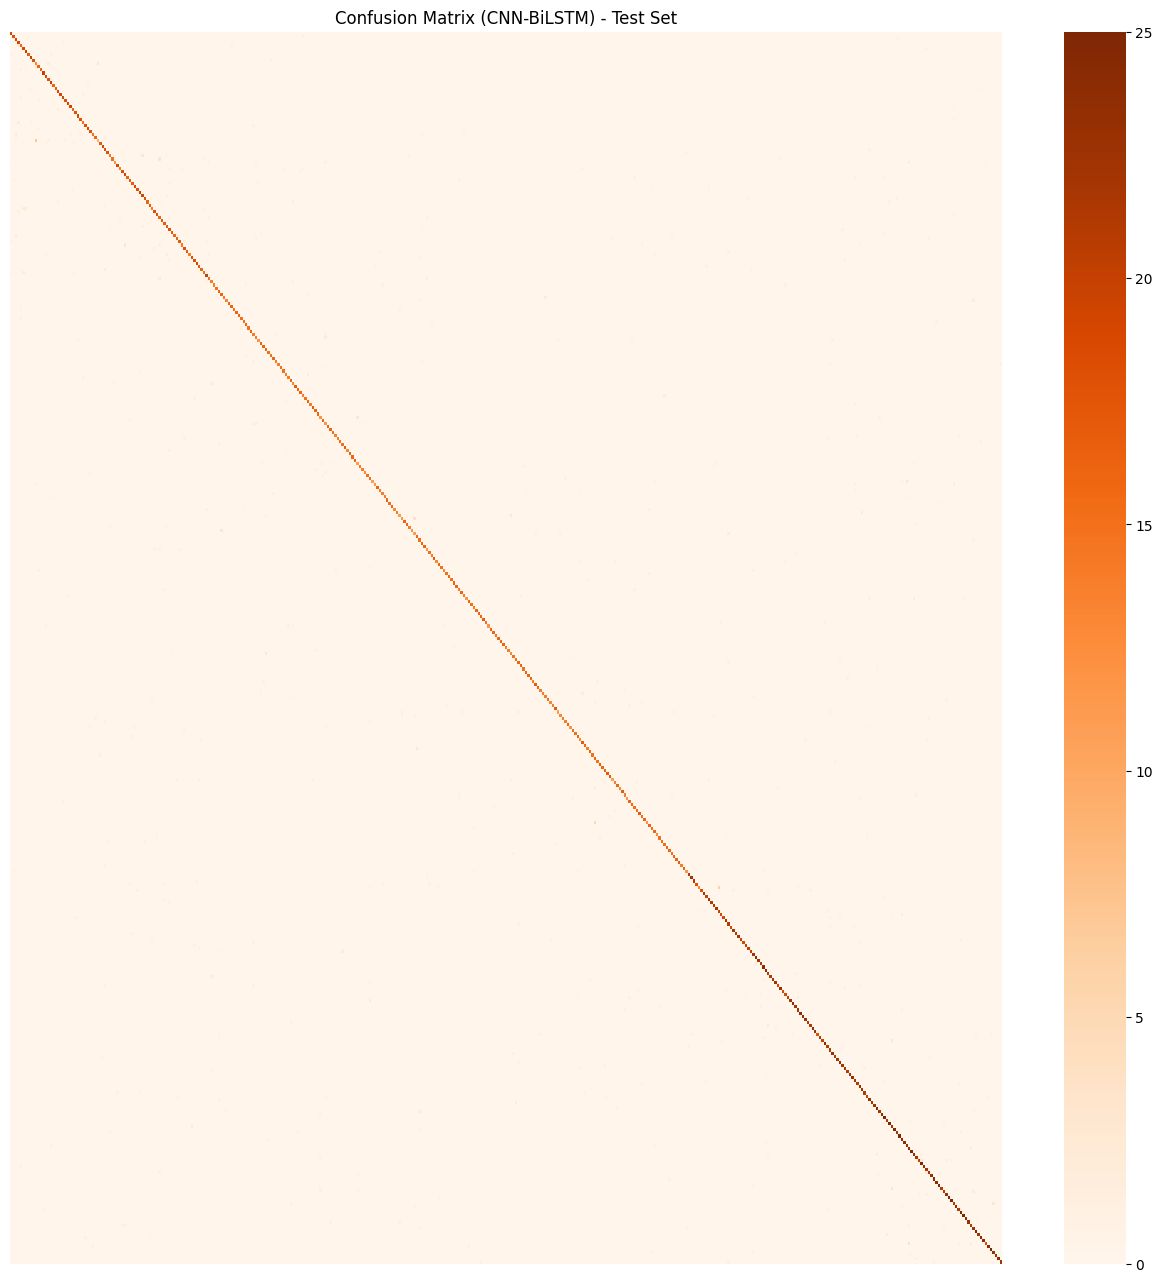

In [7]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(16, 16))
sns.heatmap(cm, cmap="Oranges", xticklabels=False, yticklabels=False)
plt.title("Confusion Matrix (CNN-BiLSTM) - Test Set")
plt.show()